In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Runge-Kutta stolen from 314 homeworks
def integrate(f, xt, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt)
    k2 = dt * f(xt+k1/2.)
    k3 = dt * f(xt+k2/2.)
    k4 = dt * f(xt+k3)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt


def simulate(f, x0, tspan, dt, integrate):
    """
    This function takes in an initial condition x0, a timestep dt,
    a time span tspan consisting of a list [min_time, max_time],
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x0. It outputs a full trajectory simulated
    over the time span of dimensions (xvec_size, time_vec_size).

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as dot{x}(t) = func(x(t))
    x0: NumPy array
        initial conditions
    tspan: Python list
        tspan = [min_time, max_time], it defines the start and end
        time of simulation
    dt:
        time step for numerical integration
    integrate: Python function
        numerical integration method used in this simulation

    Return
    ============
    x_traj:
        simulated trajectory of x(t) from t=0 to tf
    """
    N = int((max(tspan)-min(tspan))/dt)
    x = np.copy(x0)
    tvec = np.linspace(min(tspan),max(tspan),N)
    xtraj = np.zeros((len(x0),N))
    for i in range(N):
        xtraj[:,i]=integrate(f,x,dt)
        x = np.copy(xtraj[:,i])
    return xtraj

In [28]:
def diff_drive_model(x, u):
    return np.array([np.cos(x[2]) * u[0], np.sin(x[2]) * u[0], u[1]])

def noisy_diff_drive(x):
    mean = np.zeros(2)
    cov = np.array([[0.04, 0], [0, 0.02]])
    noise = np.random.multivariate_normal(mean, cov)
    u = np.array([.5, -.63]) + noise
    return diff_drive_model(x, u)

measure_cov = [[.004, 0.0, 0.0],
               [0.0, .004, 0.0],
               [0.0, 0.0, .002]]
measure_norm = 1 / 2 * np.pi * np.sqrt(np.linalg.det(measure_cov))

def p_robot(particle, measurement):
    diff = measurement - particle
    exponent = -0.5 * diff @ np.linalg.inv(measure_cov) @ diff
    return measure_norm * np.exp(exponent)

In [30]:
steps = [0, 20, 40, 60, 80, 99]

x0 = np.array([0, 0, np.pi/2])
robotraj = simulate(noisy_diff_drive, x0, [0,5], 0.05, integrate)

num_particles = 1000
init_cov = [[1e-3, 0.0, 0.0],
            [0.0, 1e-3, 0.0],
            [0.0, 0.0, 1e-4]]

particles = np.random.multivariate_normal(x0, init_cov, size=num_particles)

no_resample_snapshots = {}
resample_snapshots = {}

for t in range(100):
    #first, update the points 
    particles_bar = np.array([integrate(noisy_diff_drive, p, .05) for p in particles])
    if t in steps:
        no_resample_snapshots[t] = particles_bar.copy()
        print(f"predict at step {t}")
    
    measurement_noise = np.random.multivariate_normal(np.zeros(3), measure_cov)
    measurement = robotraj.T[t] + measurement_noise

    weights = np.array([p_robot(p, measurement) for p in particles_bar])
    weights /= weights.sum()

    indices = np.random.choice(len(particles), size=len(particles), p=weights)
    particles = particles_bar[indices]

    if t in steps:
        resample_snapshots[t] = particles.copy()
        print(f"resample step {t}")



predict at step 0
resample step 0
predict at step 20
resample step 20
predict at step 40
resample step 40
predict at step 60
resample step 60
predict at step 80
resample step 80
predict at step 99
resample step 99


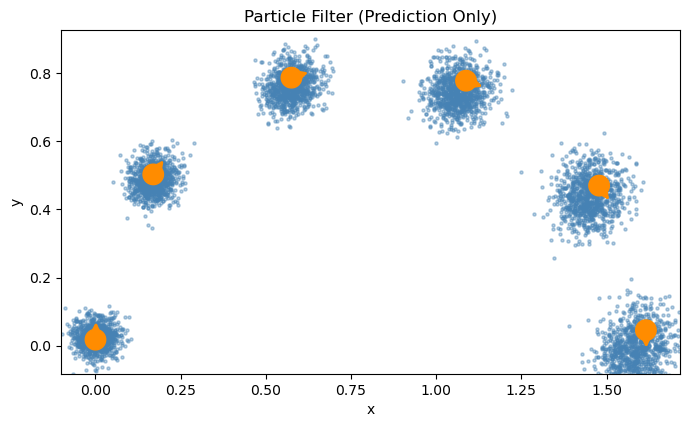

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

margin = 0.1
ax.set_xlim(robotraj[0].min() - margin, robotraj[0].max() + margin)
ax.set_ylim(robotraj[1].min() - margin, robotraj[1].max() + margin)
ax.set_aspect('equal')

r = 0.03
t = np.linspace(0, 2 * np.pi, 100)
poses = robotraj[:, steps].T

for step, (x, y, theta) in zip(steps, poses):
    # Particles
    cloud = no_resample_snapshots[step]
    ax.scatter(cloud[:, 0], cloud[:, 1], s=5, alpha=0.4, color='steelblue', zorder=2)
    # Ground truth pose
    ax.fill(x + r * np.cos(t), y + r * np.sin(t), color='darkorange', zorder=5)
    ax.annotate(
        "",
        xy=(x + r * 2 * np.cos(theta), y + r * 2 * np.sin(theta)),
        xytext=(x, y),
        arrowprops=dict(arrowstyle="-|>", color='darkorange', lw=2),
        zorder=6
    )

ax.set_title("Particle Filter (Prediction Only)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

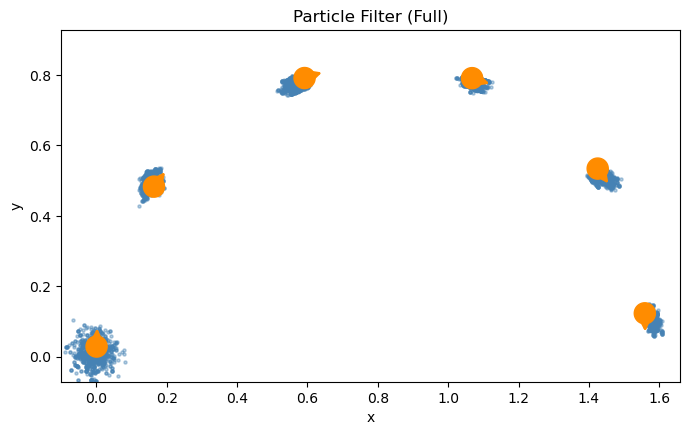

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

margin = 0.1
ax.set_xlim(robotraj[0].min() - margin, robotraj[0].max() + margin)
ax.set_ylim(robotraj[1].min() - margin, robotraj[1].max() + margin)
ax.set_aspect('equal')

r = 0.03
t = np.linspace(0, 2 * np.pi, 100)
poses = robotraj[:, steps].T

for step, (x, y, theta) in zip(steps, poses):
    # Particles
    cloud = resample_snapshots[step]
    ax.scatter(cloud[:, 0], cloud[:, 1], s=5, alpha=0.4, color='steelblue', zorder=2)
    # Ground truth pose
    ax.fill(x + r * np.cos(t), y + r * np.sin(t), color='darkorange', zorder=5)
    ax.annotate(
        "",
        xy=(x + r * 2 * np.cos(theta), y + r * 2 * np.sin(theta)),
        xytext=(x, y),
        arrowprops=dict(arrowstyle="-|>", color='darkorange', lw=2),
        zorder=6
    )

ax.set_title("Particle Filter (Full)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()